# Chapter 8: Eigenvalues and Eigenvectors

**Book:** *Linear Algebra with Applications in Machine Learning: From Intuitive Understanding to Python Coding*

---

Eigenvalues and eigenvectors decode the intrinsic behavior of linear transformations: they identify directions that remain invariant under the transformation, merely scaled by a factor $\lambda$. These "natural axes" simplify complex matrix operations and underpin PCA, spectral clustering, and optimization. This notebook covers:

1. **Definition and Basics** — $A\mathbf{v} = \lambda\mathbf{v}$, eigenspaces, geometric interpretation
2. **Computing Eigenvalues** — characteristic polynomial $\det(A - \lambda I) = 0$
3. **Computing Eigenvectors** — solving $(A - \lambda I)\mathbf{v} = \mathbf{0}$
4. **Eigenspaces and Multiplicities** — algebraic vs. geometric multiplicity
5. **Diagonalization** — $A = PDP^{-1}$, conditions, examples
6. **Properties** — orthogonality of symmetric matrices, trace/det connections
7. **Eigenvalues in ML** — PCA, spectral clustering, optimization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
np.set_printoptions(precision=4, suppress=True)

print("All imports successful.")

All imports successful.


## 8.1 Eigenvalues and Eigenvectors: Definition

For a square matrix $A \in \mathbb{R}^{n \times n}$, a nonzero vector $\mathbf{v}$ is an **eigenvector** if:

$$A\mathbf{v} = \lambda \mathbf{v}$$

The scalar $\lambda$ is the corresponding **eigenvalue**. This means $A$ acts on $\mathbf{v}$ by simply scaling it, without changing its direction.

- $\lambda > 1$: stretches the vector
- $0 < \lambda < 1$: shrinks it
- $\lambda < 0$: flips and scales
- $\lambda = 0$: collapses to zero (singular matrix)

In [2]:
# Simplest example: diagonal matrix
A = np.array([[2, 0],
              [0, 3]])

v1 = np.array([1, 0])
v2 = np.array([0, 1])

print(f"A @ v1 = {A @ v1} = {2} * {v1}  =>  eigenvalue = 2")
print(f"A @ v2 = {A @ v2} = {3} * {v2}  =>  eigenvalue = 3")

A @ v1 = [2 0] = 2 * [1 0]  =>  eigenvalue = 2
A @ v2 = [0 3] = 3 * [0 1]  =>  eigenvalue = 3


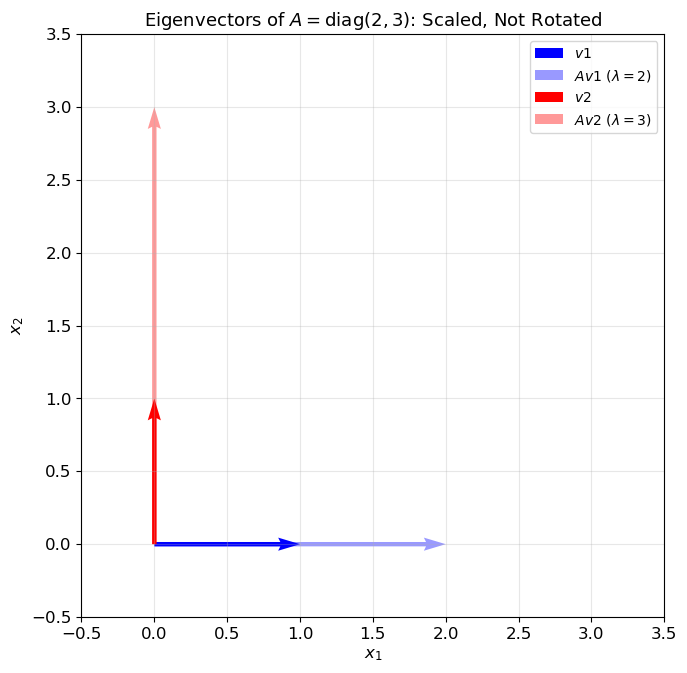

In [3]:
# Visualize: eigenvectors before and after transformation
fig, ax = plt.subplots(figsize=(7, 7))

for v, lam, color, name in [(v1, 2, 'blue', 'v1'), (v2, 3, 'red', 'v2')]:
    Av = A @ v
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
              color=color, linewidth=2.5, label=rf'${name}$')
    ax.quiver(0, 0, Av[0], Av[1], angles='xy', scale_units='xy', scale=1,
              color=color, linewidth=2, alpha=0.4, linestyle='dashed',
              label=rf'$A{name}$ ($\lambda={lam}$)')

ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3.5)
ax.set_aspect('equal')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title(r'Eigenvectors of $A = \mathrm{diag}(2, 3)$: Scaled, Not Rotated', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Verifying an Eigenvector

In [4]:
# 3x3 verification
A = np.array([[5, 2, 1],
              [-2, 1, -1],
              [2, 2, 4]])
v = np.array([1, -1, 1])
lam = 4

Av = A @ v
lam_v = lam * v

print(f"A @ v  = {Av}")
print(f"{lam}*v = {lam_v}")
print(f"A @ v == lambda*v? {np.allclose(Av, lam_v)}")
print(f"=> v = {v} is an eigenvector with lambda = {lam}")

A @ v  = [ 4 -4  4]
4*v = [ 4 -4  4]
A @ v == lambda*v? True
=> v = [ 1 -1  1] is an eigenvector with lambda = 4


### What Happens to Non-Eigenvectors?

Most vectors change direction under $A$. Only eigenvectors stay aligned.

Eigenvalues: [3. 1.]
Eigenvectors:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


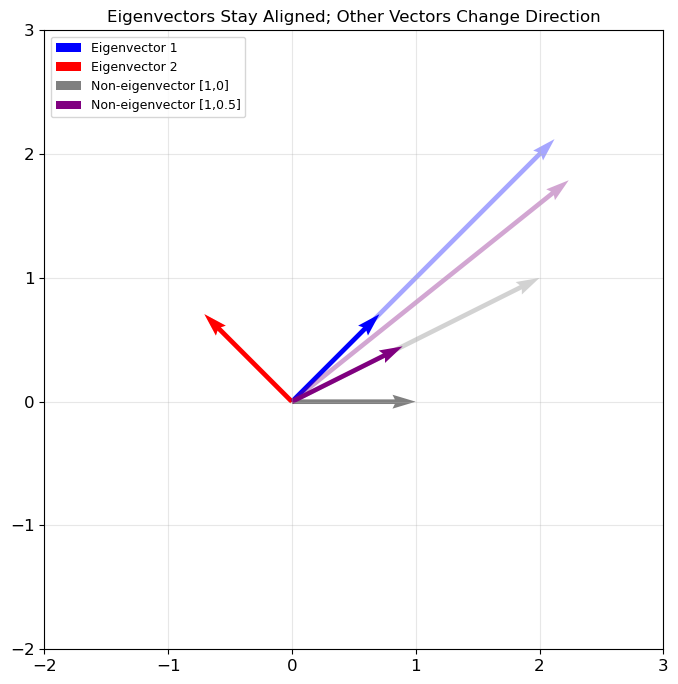

In [5]:
A = np.array([[2, 1],
              [1, 2]])

# Compute eigenvectors
eigvals, eigvecs = np.linalg.eig(A)
print(f"Eigenvalues: {eigvals}")
print(f"Eigenvectors:\n{eigvecs}")

fig, ax = plt.subplots(figsize=(7, 7))

# Test vectors: some are eigenvectors, some are not
test_vectors = [
    (eigvecs[:, 0], 'blue', 'Eigenvector 1'),
    (eigvecs[:, 1], 'red', 'Eigenvector 2'),
    (np.array([1, 0]), 'gray', 'Non-eigenvector [1,0]'),
    (np.array([1, 0.5]), 'purple', 'Non-eigenvector [1,0.5]'),
]

for v, color, label in test_vectors:
    v_norm = v / np.linalg.norm(v)
    Av = A @ v_norm
    ax.quiver(0, 0, v_norm[0], v_norm[1], angles='xy', scale_units='xy', scale=1,
              color=color, linewidth=2.5, label=label)
    ax.quiver(0, 0, Av[0], Av[1], angles='xy', scale_units='xy', scale=1,
              color=color, linewidth=1.5, alpha=0.35)

ax.set_xlim(-2, 3)
ax.set_ylim(-2, 3)
ax.set_aspect('equal')
ax.set_title('Eigenvectors Stay Aligned; Other Vectors Change Direction', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8.2 Computing Eigenvalues

Eigenvalues are the roots of the **characteristic polynomial**:

$$\det(A - \lambda I) = 0$$

For a $2 \times 2$ matrix $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$, this gives:

$$\lambda^2 - (a+d)\lambda + (ad-bc) = 0 \quad \text{i.e.} \quad \lambda^2 - \text{tr}(A)\lambda + \det(A) = 0$$

In [6]:
# Example: A = [[1, 1], [4, 1]]
A = sp.Matrix([[1, 1],
               [4, 1]])
lam = sp.Symbol('lambda')

char_matrix = A - lam * sp.eye(2)
char_poly = char_matrix.det()

print("A =")
sp.pprint(A)
print(f"\nCharacteristic polynomial: {char_poly}")
print(f"Factored: {sp.factor(char_poly)}")

eigenvalues = sp.solve(char_poly, lam)
print(f"Eigenvalues: {eigenvalues}")

A =
⎡1  1⎤
⎢    ⎥
⎣4  1⎦

Characteristic polynomial: lambda**2 - 2*lambda - 3
Factored: (lambda - 3)*(lambda + 1)
Eigenvalues: [-1, 3]


In [7]:
# Trace-determinant shortcut for 2x2
A_np = np.array([[1, 1], [4, 1]], dtype=float)
tr = np.trace(A_np)
det = np.linalg.det(A_np)
# lambda^2 - tr*lambda + det = 0
disc = tr**2 - 4*det
lam1 = (tr + np.sqrt(disc)) / 2
lam2 = (tr - np.sqrt(disc)) / 2

print(f"tr(A) = {tr}, det(A) = {det}")
print(f"Characteristic eq: lambda^2 - {tr}*lambda + ({det}) = 0")
print(f"Eigenvalues (formula): {lam1}, {lam2}")
print(f"Eigenvalues (numpy):  {np.linalg.eigvals(A_np)}")

tr(A) = 2.0, det(A) = -2.9999999999999996
Characteristic eq: lambda^2 - 2.0*lambda + (-2.9999999999999996) = 0
Eigenvalues (formula): 3.0, -0.9999999999999998
Eigenvalues (numpy):  [ 3. -1.]


### Triangular Matrices: Eigenvalues = Diagonal Entries

In [8]:
T = np.array([[1, 0, 0],
              [3, -2, 0],
              [2, 3, 4]])

eigvals_T = np.linalg.eigvals(T)
print(f"Lower triangular T:\n{T}")
print(f"\nDiagonal entries: {np.diag(T)}")
print(f"Eigenvalues:      {np.sort(eigvals_T)}")
print("For triangular matrices, eigenvalues are always the diagonal entries.")

Lower triangular T:
[[ 1  0  0]
 [ 3 -2  0]
 [ 2  3  4]]

Diagonal entries: [ 1 -2  4]
Eigenvalues:      [-2.  1.  4.]
For triangular matrices, eigenvalues are always the diagonal entries.


### 3x3 Example with SymPy

In [9]:
A3 = sp.Matrix([[2, 0, 0],
                [0, 4, 5],
                [0, 4, 3]])

print("A =")
sp.pprint(A3)

# Full eigenvalue/eigenvector decomposition
eigen_data = A3.eigenvects()
print("\nEigenvalues, multiplicities, and eigenvectors:")
for val, mult, vecs in eigen_data:
    print(f"  lambda = {val} (multiplicity {mult})")
    for v in vecs:
        print(f"    eigenvector: {v.T}")

A =
⎡2  0  0⎤
⎢       ⎥
⎢0  4  5⎥
⎢       ⎥
⎣0  4  3⎦

Eigenvalues, multiplicities, and eigenvectors:
  lambda = -1 (multiplicity 1)
    eigenvector: Matrix([[0, -1, 1]])
  lambda = 2 (multiplicity 1)
    eigenvector: Matrix([[1, 0, 0]])
  lambda = 8 (multiplicity 1)
    eigenvector: Matrix([[0, 5/4, 1]])


## 8.3 Computing Eigenvectors

For each eigenvalue $\lambda$, solve the homogeneous system:

$$(A - \lambda I)\mathbf{v} = \mathbf{0}$$

The solution space (null space of $A - \lambda I$) is the **eigenspace** for $\lambda$.

In [10]:
# Step-by-step for A = [[1, 1], [4, 1]]
A = sp.Matrix([[1, 1], [4, 1]])
print("A =")
sp.pprint(A)

for lam_val in [3, -1]:
    print(f"\n--- lambda = {lam_val} ---")
    M = A - lam_val * sp.eye(2)
    print(f"A - {lam_val}*I =")
    sp.pprint(M)
    
    rref, pivots = M.rref()
    print(f"RREF:")
    sp.pprint(rref)
    
    null = M.nullspace()
    print(f"Eigenspace (null space):")
    for v in null:
        print(f"  span({v.T})")
    
    # Verify
    v_test = null[0]
    Av = A * v_test
    lv = lam_val * v_test
    print(f"Verify: A*v = {Av.T}, lambda*v = {lv.T}, equal: {Av.equals(lv)}")

A =
⎡1  1⎤
⎢    ⎥
⎣4  1⎦

--- lambda = 3 ---
A - 3*I =
⎡-2  1 ⎤
⎢      ⎥
⎣4   -2⎦
RREF:
⎡1  -1/2⎤
⎢       ⎥
⎣0   0  ⎦
Eigenspace (null space):
  span(Matrix([[1/2, 1]]))
Verify: A*v = Matrix([[3/2, 3]]), lambda*v = Matrix([[3/2, 3]]), equal: True

--- lambda = -1 ---
A - -1*I =
⎡2  1⎤
⎢    ⎥
⎣4  2⎦
RREF:
⎡1  1/2⎤
⎢      ⎥
⎣0   0 ⎦
Eigenspace (null space):
  span(Matrix([[-1/2, 1]]))
Verify: A*v = Matrix([[1/2, -1]]), lambda*v = Matrix([[1/2, -1]]), equal: True


In [11]:
# NumPy computation for the same matrix
A_np = np.array([[1, 1], [4, 1]], dtype=float)
eigvals, eigvecs = np.linalg.eig(A_np)

print(f"Eigenvalues: {eigvals}")
print(f"Eigenvectors (as columns):\n{eigvecs}")

# Verify each
for i in range(len(eigvals)):
    v = eigvecs[:, i]
    lam = eigvals[i]
    print(f"\nlambda={lam:.1f}: A@v = {(A_np @ v).round(4)}, lambda*v = {(lam * v).round(4)}")

Eigenvalues: [ 3. -1.]
Eigenvectors (as columns):
[[ 0.4472 -0.4472]
 [ 0.8944  0.8944]]

lambda=3.0: A@v = [1.3416 2.6833], lambda*v = [1.3416 2.6833]

lambda=-1.0: A@v = [ 0.4472 -0.8944], lambda*v = [ 0.4472 -0.8944]


### Visualizing Eigenvectors and Their Transforms

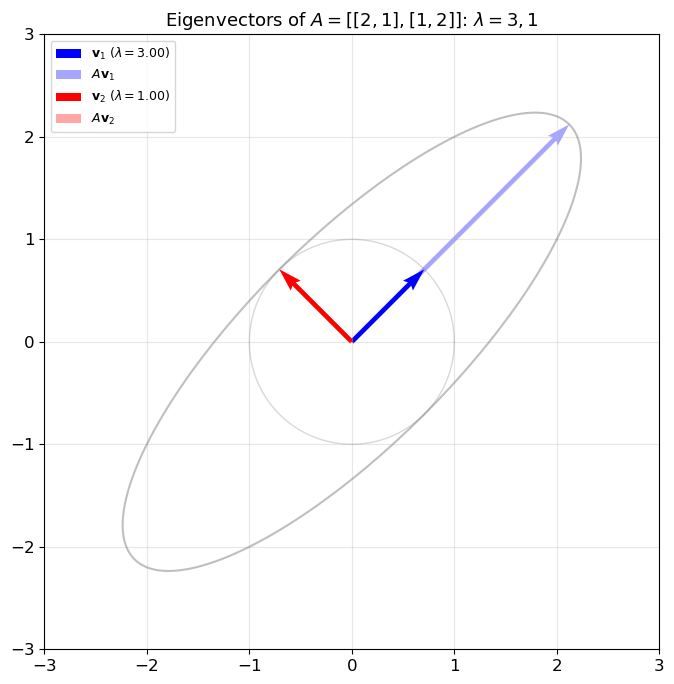

In [12]:
def plot_eigenvectors(A, title=''):
    """Visualize eigenvectors and how A transforms them."""
    eigvals, eigvecs = np.linalg.eig(A)
    
    fig, ax = plt.subplots(figsize=(7, 7))
    colors = ['blue', 'red', 'green']
    
    # Also show how A transforms the unit circle
    theta = np.linspace(0, 2*np.pi, 200)
    circle = np.array([np.cos(theta), np.sin(theta)])
    ellipse = A @ circle
    ax.plot(circle[0], circle[1], 'gray', linewidth=1, alpha=0.3)
    ax.plot(ellipse[0], ellipse[1], 'gray', linewidth=1.5, alpha=0.5)
    
    for i in range(len(eigvals)):
        if np.isreal(eigvals[i]):
            v = eigvecs[:, i].real
            lam = eigvals[i].real
            Av = A @ v
            c = colors[i % len(colors)]
            
            ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                      color=c, linewidth=2.5,
                      label=rf'$\mathbf{{v}}_{i+1}$ ($\lambda={lam:.2f}$)')
            ax.quiver(0, 0, Av[0], Av[1], angles='xy', scale_units='xy', scale=1,
                      color=c, linewidth=2, alpha=0.35,
                      label=rf'$A\mathbf{{v}}_{i+1}$')
    
    lim = max(3, np.max(np.abs(ellipse)) + 0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_title(f'{title}', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_eigenvectors(np.array([[2, 1], [1, 2]]),
                  r'Eigenvectors of $A = [[2,1],[1,2]]$: $\lambda = 3, 1$')

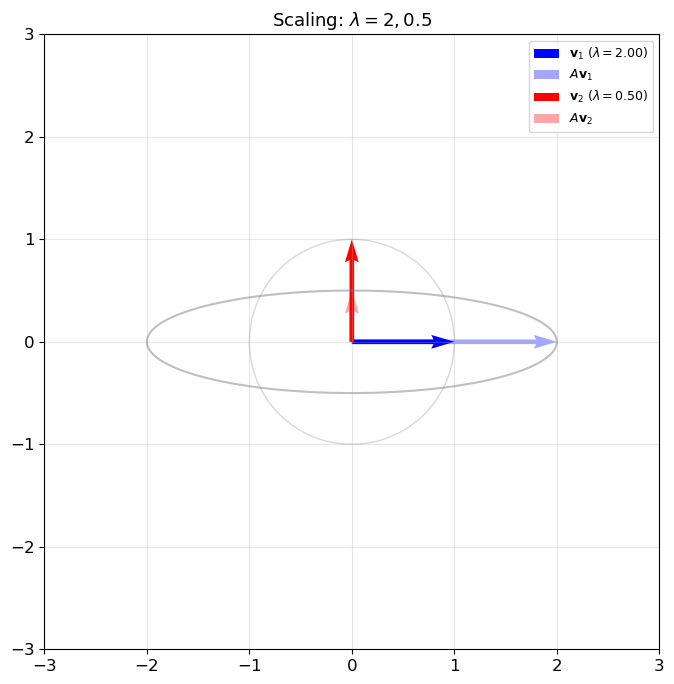

In [13]:
# Scaling matrix: stretches x, compresses y
plot_eigenvectors(np.array([[2, 0], [0, 0.5]]),
                  r'Scaling: $\lambda = 2, 0.5$')

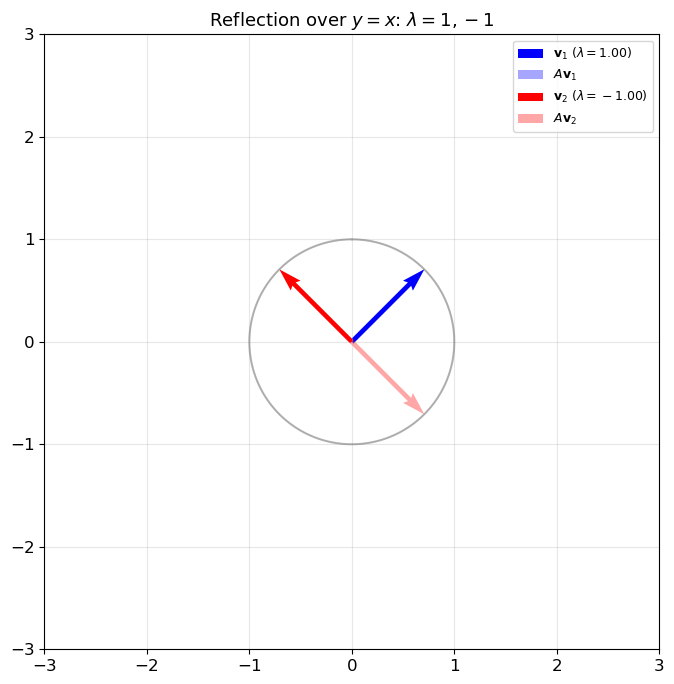

In [14]:
# Reflection over y=x: lambda = 1 (along y=x), lambda = -1 (perpendicular)
plot_eigenvectors(np.array([[0, 1], [1, 0]]),
                  r'Reflection over $y=x$: $\lambda = 1, -1$')

### Complex Eigenvalues: Rotation

A pure rotation has no real invariant directions. Its eigenvalues are complex: $\lambda = e^{\pm i\theta}$.

In [15]:
# 90-degree rotation: no real eigenvectors
R = np.array([[0, -1],
              [1,  0]])

eigvals_R = np.linalg.eigvals(R)
print(f"Rotation matrix R:\n{R}")
print(f"Eigenvalues: {eigvals_R}")
print(f"Both are complex (imaginary): no real vector stays aligned under rotation.")

Rotation matrix R:
[[ 0 -1]
 [ 1  0]]
Eigenvalues: [0.+1.j 0.-1.j]
Both are complex (imaginary): no real vector stays aligned under rotation.


## 8.4 Eigenspaces and Multiplicities

The **eigenspace** for $\lambda$ is $\text{Null}(A - \lambda I)$, a subspace of $\mathbb{R}^n$.

- **Algebraic multiplicity:** how many times $\lambda$ appears as a root of the characteristic polynomial
- **Geometric multiplicity:** dimension of the eigenspace ($= \dim(\text{Null}(A - \lambda I))$)

Always: $1 \leq \text{geom. mult.} \leq \text{alg. mult.}$

In [16]:
# Example with repeated eigenvalue: lambda = -1 has algebraic mult. 2
A = sp.Matrix([[-1, 0, 0],
               [0, 1, 2],
               [0, 2, 1]])

print("A =")
sp.pprint(A)

# Characteristic polynomial
lam = sp.Symbol('lambda')
cp = (A - lam * sp.eye(3)).det()
print(f"\nCharacteristic polynomial: {sp.factor(cp)}")

# Eigenvalues with multiplicities
eigen_data = A.eigenvects()
print("\nEigenvalue analysis:")
for val, alg_mult, vecs in eigen_data:
    geom_mult = len(vecs)
    print(f"  lambda = {val}:  alg. mult. = {alg_mult},  geom. mult. = {geom_mult}")
    for v in vecs:
        print(f"    eigenvector: {v.T}")
    match = "=" if alg_mult == geom_mult else "<"
    print(f"    geom {match} alg")

A =
⎡-1  0  0⎤
⎢        ⎥
⎢0   1  2⎥
⎢        ⎥
⎣0   2  1⎦

Characteristic polynomial: -(lambda - 3)*(lambda + 1)**2

Eigenvalue analysis:
  lambda = -1:  alg. mult. = 2,  geom. mult. = 2
    eigenvector: Matrix([[1, 0, 0]])
    eigenvector: Matrix([[0, -1, 1]])
    geom = alg
  lambda = 3:  alg. mult. = 1,  geom. mult. = 1
    eigenvector: Matrix([[0, 1, 1]])
    geom = alg


In [17]:
# Case where geometric < algebraic => NOT diagonalizable
A_nd = sp.Matrix([[0, 1],
                  [0, 0]])

print("A (not diagonalizable) =")
sp.pprint(A_nd)

eigen_nd = A_nd.eigenvects()
print("\nEigenvalue analysis:")
for val, alg_mult, vecs in eigen_nd:
    geom_mult = len(vecs)
    print(f"  lambda = {val}: alg. mult. = {alg_mult}, geom. mult. = {geom_mult}")
    print(f"  geom ({geom_mult}) < alg ({alg_mult}) => NOT enough eigenvectors!")

A (not diagonalizable) =
⎡0  1⎤
⎢    ⎥
⎣0  0⎦

Eigenvalue analysis:
  lambda = 0: alg. mult. = 2, geom. mult. = 1
  geom (1) < alg (2) => NOT enough eigenvectors!


## 8.5 Diagonalization

A matrix $A$ is **diagonalizable** if $A = PDP^{-1}$, where:
- $P$: matrix whose columns are $n$ linearly independent eigenvectors
- $D$: diagonal matrix of corresponding eigenvalues

**Condition:** $A$ is diagonalizable iff geometric multiplicity = algebraic multiplicity for every eigenvalue.

**Sufficient condition:** $n$ distinct eigenvalues always guarantee diagonalizability.

In [18]:
def check_diagonalizable(A_sym, name='A'):
    """Check diagonalizability and compute P, D if possible."""
    print(f"=== {name} ===")
    sp.pprint(A_sym)
    
    eigen_data = A_sym.eigenvects()
    n = A_sym.shape[0]
    total_geom = 0
    diagonalizable = True
    
    print("\nEigenvalues:")
    for val, alg, vecs in eigen_data:
        geom = len(vecs)
        total_geom += geom
        status = 'OK' if geom == alg else 'DEFICIENT'
        if geom < alg:
            diagonalizable = False
        print(f"  lambda={val}: alg={alg}, geom={geom} [{status}]")
    
    print(f"\nTotal eigenvectors: {total_geom}, Matrix size: {n}")
    print(f"Diagonalizable: {diagonalizable}")
    
    if diagonalizable:
        P, D = A_sym.diagonalize()
        print(f"\nP =")
        sp.pprint(P)
        print(f"D =")
        sp.pprint(D)
        # Verify
        reconstructed = P * D * P.inv()
        print(f"P D P^(-1) == A? {reconstructed.equals(A_sym)}")
    print()

# Case 1: Diagonalizable (distinct eigenvalues)
check_diagonalizable(sp.Matrix([[1, 1], [4, 1]]), 'Distinct eigenvalues')

# Case 2: Diagonalizable (repeated eigenvalue, sufficient eigenvectors)
check_diagonalizable(sp.Matrix([[-1,0,0],[0,1,2],[0,2,1]]), 'Repeated lambda, sufficient eigenvectors')

# Case 3: NOT diagonalizable (deficient eigenspace)
check_diagonalizable(sp.Matrix([[0, 1], [0, 0]]), 'Deficient eigenspace')

=== Distinct eigenvalues ===
⎡1  1⎤
⎢    ⎥
⎣4  1⎦

Eigenvalues:
  lambda=-1: alg=1, geom=1 [OK]
  lambda=3: alg=1, geom=1 [OK]

Total eigenvectors: 2, Matrix size: 2
Diagonalizable: True

P =
⎡-1  1⎤
⎢     ⎥
⎣2   2⎦
D =
⎡-1  0⎤
⎢     ⎥
⎣0   3⎦
P D P^(-1) == A? True

=== Repeated lambda, sufficient eigenvectors ===
⎡-1  0  0⎤
⎢        ⎥
⎢0   1  2⎥
⎢        ⎥
⎣0   2  1⎦

Eigenvalues:
  lambda=-1: alg=2, geom=2 [OK]
  lambda=3: alg=1, geom=1 [OK]

Total eigenvectors: 3, Matrix size: 3
Diagonalizable: True

P =
⎡1  0   0⎤
⎢        ⎥
⎢0  -1  1⎥
⎢        ⎥
⎣0  1   1⎦
D =
⎡-1  0   0⎤
⎢         ⎥
⎢0   -1  0⎥
⎢         ⎥
⎣0   0   3⎦
P D P^(-1) == A? True

=== Deficient eigenspace ===
⎡0  1⎤
⎢    ⎥
⎣0  0⎦

Eigenvalues:
  lambda=0: alg=2, geom=1 [DEFICIENT]

Total eigenvectors: 1, Matrix size: 2
Diagonalizable: False



In [19]:
# NumPy diagonalization and verification
A = np.array([[-1, 0, 0],
              [ 0, 1, 2],
              [ 0, 2, 1]], dtype=float)

eigenvalues, P = np.linalg.eig(A)
D = np.diag(eigenvalues)
A_reconstructed = P @ D @ np.linalg.inv(P)

print(f"Eigenvalues: {eigenvalues}")
print(f"\nP (eigenvectors as columns):\n{P.round(4)}")
print(f"\nD (diagonal of eigenvalues):\n{D.round(4)}")
print(f"\nP @ D @ P^(-1):\n{A_reconstructed.round(4)}")
print(f"\nOriginal A:\n{A}")
print(f"Match: {np.allclose(A, A_reconstructed)}")

Eigenvalues: [ 3. -1. -1.]

P (eigenvectors as columns):
[[ 0.      0.      1.    ]
 [ 0.7071  0.7071  0.    ]
 [ 0.7071 -0.7071  0.    ]]

D (diagonal of eigenvalues):
[[ 3.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]

P @ D @ P^(-1):
[[-1.  0.  0.]
 [ 0.  1.  2.]
 [ 0.  2.  1.]]

Original A:
[[-1.  0.  0.]
 [ 0.  1.  2.]
 [ 0.  2.  1.]]
Match: True


### Power of a Diagonal Matrix

One key benefit of diagonalization: $A^k = P D^k P^{-1}$, and $D^k$ is trivial to compute.

In [20]:
# Compute A^10 via diagonalization
A = np.array([[2, 1], [1, 2]], dtype=float)
eigenvalues, P = np.linalg.eig(A)
D = np.diag(eigenvalues)
P_inv = np.linalg.inv(P)

k = 10
D_k = np.diag(eigenvalues**k)
A_k_diag = P @ D_k @ P_inv
A_k_direct = np.linalg.matrix_power(A, k)

print(f"A^{k} via diagonalization:\n{A_k_diag.round(2)}")
print(f"\nA^{k} via direct computation:\n{A_k_direct.round(2)}")
print(f"\nMatch: {np.allclose(A_k_diag, A_k_direct)}")

A^10 via diagonalization:
[[29525. 29524.]
 [29524. 29525.]]

A^10 via direct computation:
[[29525. 29524.]
 [29524. 29525.]]

Match: True


## 8.6 Properties of Eigenvalues and Eigenvectors

### Trace and Determinant from Eigenvalues

For any $n \times n$ matrix:
- $\text{tr}(A) = \sum \lambda_i$ (sum of eigenvalues)
- $\det(A) = \prod \lambda_i$ (product of eigenvalues)

In [21]:
A = np.array([[2, 1], [1, 2]], dtype=float)
eigvals = np.linalg.eigvals(A)

print(f"A =\n{A}")
print(f"Eigenvalues: {eigvals}")
print(f"\ntr(A) = {np.trace(A):.2f},  sum(lambda) = {np.sum(eigvals):.2f}")
print(f"det(A) = {np.linalg.det(A):.2f},  prod(lambda) = {np.prod(eigvals):.2f}")

A =
[[2. 1.]
 [1. 2.]]
Eigenvalues: [3. 1.]

tr(A) = 4.00,  sum(lambda) = 4.00
det(A) = 3.00,  prod(lambda) = 3.00


### Orthogonality for Symmetric Matrices

If $A = A^T$ (symmetric), then eigenvectors for **distinct** eigenvalues are **orthogonal**. This is the spectral theorem, and it is why PCA works so cleanly.

In [22]:
# Symmetric matrix
A_sym = np.array([[3, 1],
                  [1, 3]], dtype=float)

eigvals_s, eigvecs_s = np.linalg.eigh(A_sym)  # eigh for symmetric
v1, v2 = eigvecs_s[:, 0], eigvecs_s[:, 1]

print(f"Symmetric A:\n{A_sym}")
print(f"Eigenvalues: {eigvals_s}")
print(f"v1 = {v1.round(4)}, v2 = {v2.round(4)}")
print(f"v1 . v2 = {np.dot(v1, v2):.6f}  (should be 0: orthogonal!)")

# Non-symmetric matrix: eigenvectors are generally NOT orthogonal
A_nonsym = np.array([[2, 3], [4, 1]], dtype=float)
eigvals_ns, eigvecs_ns = np.linalg.eig(A_nonsym)
w1, w2 = eigvecs_ns[:, 0], eigvecs_ns[:, 1]

print(f"\nNon-symmetric A:\n{A_nonsym}")
print(f"w1 . w2 = {np.dot(w1, w2):.6f}  (NOT necessarily 0)")

Symmetric A:
[[3. 1.]
 [1. 3.]]
Eigenvalues: [2. 4.]
v1 = [-0.7071  0.7071], v2 = [0.7071 0.7071]
v1 . v2 = 0.000000  (should be 0: orthogonal!)

Non-symmetric A:
[[2. 3.]
 [4. 1.]]
w1 . w2 = 0.141421  (NOT necessarily 0)


## 8.7 Comprehensive Matrix Analysis

Let us put everything together for a single matrix: eigenvalues, eigenvectors, trace, determinant, rank, diagonalizability.

In [23]:
def full_eigen_analysis(A_np, name='A'):
    """Complete eigenvalue/eigenvector analysis of a matrix."""
    n = A_np.shape[0]
    eigvals, eigvecs = np.linalg.eig(A_np)
    
    print(f"=== Analysis of {name} ===")
    print(f"Matrix:\n{A_np}")
    print(f"\nSize: {n}x{n}")
    print(f"Trace: {np.trace(A_np):.4f}  (= sum of eigenvalues: {np.sum(eigvals).real:.4f})")
    print(f"Determinant: {np.linalg.det(A_np):.4f}  (= product of eigenvalues: {np.prod(eigvals).real:.4f})")
    print(f"Rank: {np.linalg.matrix_rank(A_np)}")
    print(f"Invertible: {abs(np.linalg.det(A_np)) > 1e-10}")
    print(f"Symmetric: {np.allclose(A_np, A_np.T)}")
    
    print(f"\nEigenvalues: {eigvals}")
    for i in range(len(eigvals)):
        lam = eigvals[i]
        v = eigvecs[:, i]
        print(f"  lambda_{i+1} = {lam:.4f},  eigenvector = {v.round(4)}")
    
    if np.allclose(A_np, A_np.T) and np.all(np.isreal(eigvals)):
        print(f"\nEigenvector orthogonality (symmetric):")
        for i in range(n):
            for j in range(i+1, n):
                dot = np.dot(eigvecs[:, i], eigvecs[:, j])
                print(f"  v{i+1} . v{j+1} = {dot:.6f}")
    print()

full_eigen_analysis(np.array([[2, 1], [1, 2]], dtype=float), 'Symmetric 2x2')
full_eigen_analysis(np.array([[2, 1], [2, 3]], dtype=float), 'Non-symmetric 2x2')
full_eigen_analysis(np.array([[1, 2], [2, 4]], dtype=float), 'Singular 2x2')

=== Analysis of Symmetric 2x2 ===
Matrix:
[[2. 1.]
 [1. 2.]]

Size: 2x2
Trace: 4.0000  (= sum of eigenvalues: 4.0000)
Determinant: 3.0000  (= product of eigenvalues: 3.0000)
Rank: 2
Invertible: True
Symmetric: True

Eigenvalues: [3. 1.]
  lambda_1 = 3.0000,  eigenvector = [0.7071 0.7071]
  lambda_2 = 1.0000,  eigenvector = [-0.7071  0.7071]

Eigenvector orthogonality (symmetric):
  v1 . v2 = 0.000000

=== Analysis of Non-symmetric 2x2 ===
Matrix:
[[2. 1.]
 [2. 3.]]

Size: 2x2
Trace: 5.0000  (= sum of eigenvalues: 5.0000)
Determinant: 4.0000  (= product of eigenvalues: 4.0000)
Rank: 2
Invertible: True
Symmetric: False

Eigenvalues: [1. 4.]
  lambda_1 = 1.0000,  eigenvector = [-0.7071  0.7071]
  lambda_2 = 4.0000,  eigenvector = [-0.4472 -0.8944]

=== Analysis of Singular 2x2 ===
Matrix:
[[1. 2.]
 [2. 4.]]

Size: 2x2
Trace: 5.0000  (= sum of eigenvalues: 5.0000)
Determinant: 0.0000  (= product of eigenvalues: 0.0000)
Rank: 1
Invertible: False
Symmetric: True

Eigenvalues: [0. 5.]
  lambd

## 8.8 Eigenvalues in Machine Learning

### 8.8.1 Principal Component Analysis (PCA)

PCA finds the directions of maximum variance in data by computing the eigenvectors of the covariance matrix. The eigenvalues tell us how much variance each direction captures.

In [24]:
# Generate correlated 2D data
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2], [2, 2]]
data = np.random.multivariate_normal(mean, cov, 300)

# Compute covariance matrix and its eigen-decomposition
C = np.cov(data.T)
eigvals_pca, eigvecs_pca = np.linalg.eigh(C)

# Sort by descending eigenvalue
idx = np.argsort(eigvals_pca)[::-1]
eigvals_pca = eigvals_pca[idx]
eigvecs_pca = eigvecs_pca[:, idx]

print(f"Covariance matrix:\n{C.round(4)}")
print(f"\nEigenvalues (variance along each PC): {eigvals_pca.round(4)}")
print(f"Explained variance ratio: {(eigvals_pca / eigvals_pca.sum() * 100).round(1)}%")
print(f"\nPrincipal components (eigenvectors):\n{eigvecs_pca.round(4)}")

Covariance matrix:
[[2.8906 1.9188]
 [1.9188 1.8937]]

Eigenvalues (variance along each PC): [4.3746 0.4096]
Explained variance ratio: [91.4  8.6]%

Principal components (eigenvectors):
[[-0.791   0.6118]
 [-0.6118 -0.791 ]]


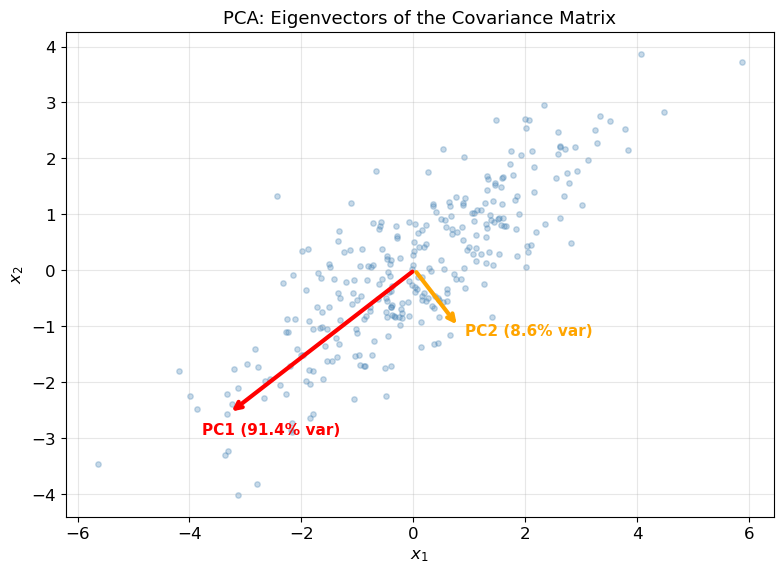

In [25]:
# Visualize PCA
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(data[:, 0], data[:, 1], alpha=0.3, s=15, color='steelblue')

origin = data.mean(axis=0)
colors = ['red', 'orange']
for i in range(2):
    direction = eigvecs_pca[:, i] * np.sqrt(eigvals_pca[i]) * 2
    ax.annotate('', xy=origin + direction, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=3))
    ax.text(*(origin + direction * 1.15),
            f'PC{i+1} ({eigvals_pca[i]/eigvals_pca.sum()*100:.1f}% var)',
            fontsize=11, fontweight='bold', color=colors[i])

ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('PCA: Eigenvectors of the Covariance Matrix', fontsize=13)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.8.2 Spectral Clustering (Conceptual)

Spectral clustering uses eigenvectors of the **graph Laplacian** $L = D - W$ (where $W$ is the adjacency/similarity matrix and $D$ is the degree matrix). The eigenvectors corresponding to the smallest nonzero eigenvalues reveal cluster structure.

In [26]:
# Simple graph: 6 nodes forming two clusters
W = np.array([
    [0, 1, 1, 0, 0, 0],
    [1, 0, 1, 0, 0, 0],
    [1, 1, 0, 0.1, 0, 0],
    [0, 0, 0.1, 0, 1, 1],
    [0, 0, 0, 1, 0, 1],
    [0, 0, 0, 1, 1, 0],
])

D = np.diag(W.sum(axis=1))
L = D - W  # Graph Laplacian

eigvals_L, eigvecs_L = np.linalg.eigh(L)

print(f"Laplacian eigenvalues: {eigvals_L.round(4)}")
print(f"\n2nd eigenvector (Fiedler vector, reveals clusters):")
fiedler = eigvecs_L[:, 1]
print(f"  {fiedler.round(4)}")
print(f"\nCluster assignment (sign of Fiedler vector):")
clusters = (fiedler > 0).astype(int)
for i in range(6):
    print(f"  Node {i}: cluster {clusters[i]}")

Laplacian eigenvalues: [0.     0.0638 3.     3.     3.     3.1362]

2nd eigenvector (Fiedler vector, reveals clusters):
  [ 0.4169  0.4169  0.3903 -0.3903 -0.4169 -0.4169]

Cluster assignment (sign of Fiedler vector):
  Node 0: cluster 1
  Node 1: cluster 1
  Node 2: cluster 1
  Node 3: cluster 0
  Node 4: cluster 0
  Node 5: cluster 0


### ML Applications Summary

| Application | Matrix | Role of Eigenvalues/Eigenvectors |
|-------------|--------|----------------------------------|
| PCA | Covariance $C = X^TX/n$ | Eigenvectors = principal directions, eigenvalues = variance |
| Spectral Clustering | Laplacian $L = D - W$ | Small eigenvalues reveal cluster structure |
| Optimization | Hessian $H$ | Eigenvalues = curvature (positive = convex) |
| Kernel Methods | Kernel matrix $K$ | Eigenvectors define feature space |
| Graph Neural Networks | Adjacency $A$ | Eigenvalues = graph frequencies |

## 8.9 Exercises

Selected exercises from the chapter.

**Exercise 1:** Compute eigenvalues and eigenvectors of $A = \begin{bmatrix} 1 & 1 \\ 0 & 2 \end{bmatrix}$.

In [27]:
# Exercise 1: Your code here


**Exercise 3:** Verify orthogonality of eigenvectors for $A = \begin{bmatrix} 3 & 1 \\ 1 & 3 \end{bmatrix}$.

In [28]:
# Exercise 3: Your code here


**Exercise 9:** Diagonalize $A = \begin{bmatrix} 2 & 0 \\ 0 & 5 \end{bmatrix}$.

In [29]:
# Exercise 9: Your code here


**Exercise 11:** Compute the characteristic polynomial of $A = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}$.

In [30]:
# Exercise 11: Your code here


**Exercise 19:** Determine if $A = \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix}$ is diagonalizable.

In [31]:
# Exercise 19: Your code here


---

## Exercise Solutions

In [32]:
# --- Solution: Exercise 1 ---
A = sp.Matrix([[1, 1], [0, 2]])
print("Eigenvalues and eigenvectors:")
for val, mult, vecs in A.eigenvects():
    print(f"  lambda = {val}: {[v.T for v in vecs]}")

Eigenvalues and eigenvectors:
  lambda = 1: [Matrix([[1, 0]])]
  lambda = 2: [Matrix([[1, 1]])]


In [33]:
# --- Solution: Exercise 3 ---
A = np.array([[3, 1], [1, 3]], dtype=float)
eigvals, eigvecs = np.linalg.eigh(A)
v1, v2 = eigvecs[:, 0], eigvecs[:, 1]
print(f"lambda = {eigvals}")
print(f"v1 = {v1.round(4)}, v2 = {v2.round(4)}")
print(f"v1 . v2 = {np.dot(v1, v2):.6f}  (orthogonal!)")

lambda = [2. 4.]
v1 = [-0.7071  0.7071], v2 = [0.7071 0.7071]
v1 . v2 = 0.000000  (orthogonal!)


In [34]:
# --- Solution: Exercise 9 ---
A = sp.Matrix([[2, 0], [0, 5]])
P, D = A.diagonalize()
print(f"P = {P}, D = {D}")
print("Already diagonal! P = I, D = A.")

P = Matrix([[1, 0], [0, 1]]), D = Matrix([[2, 0], [0, 5]])
Already diagonal! P = I, D = A.


In [35]:
# --- Solution: Exercise 11 ---
A = sp.Matrix([[2, 1], [1, 2]])
lam = sp.Symbol('lambda')
cp = (A - lam * sp.eye(2)).det()
print(f"Characteristic polynomial: {sp.expand(cp)}")
print(f"Factored: {sp.factor(cp)}")
print(f"Eigenvalues: {sp.solve(cp, lam)}")

Characteristic polynomial: lambda**2 - 4*lambda + 3
Factored: (lambda - 3)*(lambda - 1)
Eigenvalues: [1, 3]


In [36]:
# --- Solution: Exercise 19 ---
A = sp.Matrix([[1, 1], [1, 1]])
print("Eigenvalue analysis:")
for val, alg, vecs in A.eigenvects():
    print(f"  lambda={val}: alg.mult.={alg}, geom.mult.={len(vecs)}")

try:
    P, D = A.diagonalize()
    print(f"\nDiagonalizable! D = {D}")
except sp.matrices.MatrixError as e:
    print(f"\nNot diagonalizable: {e}")

Eigenvalue analysis:
  lambda=0: alg.mult.=1, geom.mult.=1
  lambda=2: alg.mult.=1, geom.mult.=1

Diagonalizable! D = Matrix([[0, 0], [0, 2]])
